In [1]:
import pandas as pd
import os
file_path = r'data\rawData'
txt_file_path = r'data\processedData'
new_path = r'd:\Desktop\PHD\reasearch\biyework\maml'
os.chdir(new_path)
# 检查当前路径是否切换成功
current_path = os.getcwd()
print(current_path)

d:\Desktop\PHD\reasearch\biyework\maml


In [8]:

all_data_new_fit_csv=r"data\processedData\FLOOR3\all_data_new_fit.csv"
location_vector_csv = r"model\v1\output\location_vector_v3.csv"

df=pd.read_csv(all_data_new_fit_csv)    
df_location = pd.read_csv(location_vector_csv)

# 1. 每个 location_id 在不同 sf 情况下的 average_rssi 和 snr 的均值和方差
location_sf_stats = df.groupby(['location_id', 'sf']).agg(
    serial_average_rssi_mean=('average_rssi', 'mean'),
    serial_average_rssi_var=('average_rssi', 'var'),
    snr_mean=('snr', 'mean'),
    # snr_var=('snr', 'var'),
    # serial_var=('rssi_variance', 'var'),
    serial_mean=('rssi_variance', 'mean'),
).reset_index()


# 2. 每个 sf 在不同 location_id 情况下的 average_rssi 和 snr 的均值和方差
sf_location_stats = df.groupby(['sf', 'location_id']).agg(
    serial_average_rssi_mean=('average_rssi', 'mean'),
    serial_average_rssi_var=('average_rssi', 'var'),
    snr_mean=('snr', 'mean'),
    # snr_var=('snr', 'var'),
    # serial_var=('rssi_variance', 'var'),
    serial_var_mean=('rssi_variance', 'mean'),
).reset_index()

# 确保 location_id 的数据类型一致
location_sf_stats['location_id'] = location_sf_stats['location_id'].astype(str)
sf_location_stats['location_id'] = sf_location_stats['location_id'].astype(str)
df_location['location_id'] = df_location['location_id'].astype(str)

# 合并 distance_true 信息到 location_sf_stats
location_sf_stats = pd.merge(location_sf_stats, df_location[['location_id', 'distance_true']], on='location_id', how='left')

# 合并 distance_true 信息到 sf_location_stats
sf_location_stats = pd.merge(sf_location_stats, df_location[['location_id', 'distance_true']], on='location_id', how='left')

# 保存
location_sf_stats.to_csv(r"data\processedData\FLOOR3\location_sf_stats.csv", index=False)
sf_location_stats.to_csv(r"data\processedData\FLOOR3\sf_location_stats.csv", index=False)


In [3]:
# 计算平均值
data=[-55,-48,-50,-51,-55,-52,-51,-48,-50,-48,-59,-48,-48,-50,-49,-53,-52,-57,-48,-48,-49,-48,-50,-48,-47,-52,-49,-48,-49]
average = sum(data) / len(data)
print("平均值:", average)

平均值: -50.3448275862069


tsne数据分布可视化

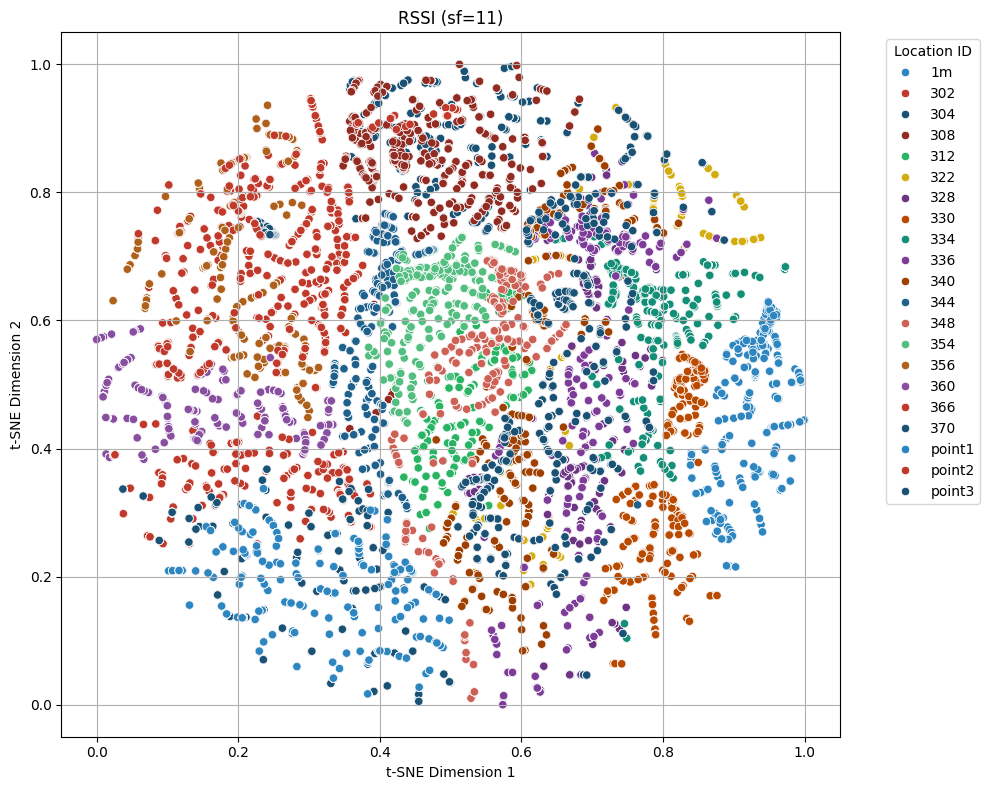

In [16]:
from sklearn.manifold import TSNE
import matplotlib.pyplot as plt
import seaborn as sns
# t-sne的输入数据需要是（batch_size,features_dim）的形式
# 1. 读取数据
file_path = r"data\processedData\FLOOR3\all_data_new.csv"   
location_vector_csv = r"model\v1\output\location_vector_v3.csv"  

location_vector = pd.read_csv(location_vector_csv)
data = pd.read_csv(file_path)
sf=11
# 2. 筛选出 sf=sf 的数据
sf_data = data[data['sf']== sf]
# location_list=["point1","370","360","350","336","1m","328","308"]
# 读取 location_vector 数据
sf_data = sf_data[sf_data['location_id'].isin(location_vector['location_id'])]
# sf_data = sf_data[sf_data['location_id'].isin(location_list)]

# features = sf_data[['average_rssi', 'snr','median_rssi','mode_rssi']].values
features = sf_data[['average_rssi', 'snr','rssi','rssi_variance']].values

tsne = TSNE(n_components=2, random_state=42,perplexity=30, max_iter=1000, learning_rate=200)
tsne_results = tsne.fit_transform(features)

# 将降维结果添加到数据框中
sf_data['tsne_1'] = tsne_results[:, 0]
sf_data['tsne_2'] = tsne_results[:, 1]
#   归一化
sf_data['tsne_1'] = (sf_data['tsne_1'] - sf_data['tsne_1'].min()) / (sf_data['tsne_1'].max() - sf_data['tsne_1'].min())
sf_data['tsne_2'] = (sf_data['tsne_2'] - sf_data['tsne_2'].min()) / (sf_data['tsne_2'].max() - sf_data['tsne_2'].min())
# 4. 可视化
plt.figure(figsize=(10, 8))
unique_labels = sf_data['location_id'].unique()
n_labels = len(unique_labels)
# 5. 设置颜色调色板
scientific_colors = [
    '#2E86C1',  # 深蓝（Pantone 7694 C）
    '#C0392B',  # 深红（Pantone 7621 C）
    '#1A5276',  # 普鲁士蓝
    '#922B21',  # 赤陶土色
    '#28B463',  # 翡翠绿
    '#D4AC0D',  # 琥珀金
    '#6C3483',  # 皇室紫
    '#BA4A00',  # 锈橙色
    '#148F77',  # 孔雀石绿
    '#7D3C98',  # 数码紫
    '#A04000',  # 深赭色
    '#1F618D',  # 钢蓝色
    '#CD6155',  # 陶土红
    '#52BE80',  # 薄荷绿
    '#AF601A',  # 皮革棕
    '#884EA0',  # 宝石紫
    '#C0392B',  # 重复色（需要时可扩展）
    '#1A5276'   # 重复色
]
palette = sns.color_palette(scientific_colors * (n_labels//len(scientific_colors)+1))[:n_labels]
sns.scatterplot(
    x='tsne_1', y='tsne_2', 
    hue='location_id', 
    palette=palette, 
    data=sf_data, 
    legend="full"
)
n_labels = len(unique_labels)

plt.title("RSSI (sf={})".format(sf))
plt.grid(True)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.legend(title='Location ID', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

In [ ]:
# 想来比较一下生成数据和预训练集中的生成数据的snr特征分布，先运行interpolation
# todo: 后续维护一下这个代码 把特征写在全局里
import numpy as np
from scipy.spatial.distance import cosine
from scipy.stats import pearsonr
pretrain_df_path=r"pretrain_df.csv"
generate_data_path=r"model\v1\output\floor3_sf_11_fake_output.csv"
num_classes=21
loc_vector_path=r"model\v1\output\location_vector_v3.csv"   
pretrain_df=pd.read_csv(pretrain_df_path)
generate_data=pd.read_csv(generate_data_path)

generate_data['snr']=generate_data['feature'].apply(lambda x: np.fromstring(x[1:-1], sep=' ') if isinstance(x, str) else x)

pretrain_df['snr'] = pretrain_df[['average_rssi', 'median_rssi', 'mode_rssi', 'snr']].apply(
    lambda row: np.tile(row.values, 4), axis=1
)
fake_output_snr = generate_data[['label', 'snr']]
pretrain_snr=pretrain_df[['location_id','snr']]

labels = set(pretrain_snr['location_id']).intersection(set(fake_output_snr['label']))
results=[]

for label in labels:
    pretrain_snr_values = pretrain_snr[pretrain_snr['location_id'] == label]['snr'].values
    fake_output_snr_values = fake_output_snr[fake_output_snr['label'] == label]['snr'].values

    # 确保两组数据长度一致（可以截断较长的部分）
    min_len = min(len(pretrain_snr_values), len(fake_output_snr_values))
    pretrain_snr_values = pretrain_snr_values[:min_len]
    pretrain_snr_values = np.array([x[:16] for x in pretrain_snr_values[:min_len]], dtype=object)
    fake_output_snr_values = np.array([x[:16] for x in fake_output_snr_values[:min_len]], dtype=object)
    cosine_sim = 1 - cosine(pretrain_snr_values.flatten(), fake_output_snr_values.flatten()) if len(pretrain_snr_values) > 0 else np.nan
    mse = np.mean((pretrain_snr_values - fake_output_snr_values) ** 2) if len(pretrain_snr_values) > 0 else np.nan
    df=pd.read_csv(loc_vector_path)
    loc_id = df[df['idx'] == label]['location_id'].values[0]
    results.append({
        'label': loc_id,
        'cosine_sim': cosine_sim,
        'mse': mse
    })

# 4. 输出结果
results_df = pd.DataFrame(results)
print(results_df)

     label  cosine_sim       mse
0   point1    0.767269  0.292610
1      370    0.767990  0.293822
2      366    0.697383  0.341448
3      360    0.670154  0.346007
4      356    0.747206  0.250914
5   point2    0.723785  0.257490
6      354    0.668951  0.267691
7      348    0.653355  0.271369
8      344    0.628215  0.303235
9      340    0.607550  0.300169
10     336    0.610852  0.263191
11     334    0.529563  0.311361
12      1m    0.558453  0.250136
13  point3    0.639802  0.250808
14     330    0.542247  0.277579
15     328    0.601036  0.275281
16     322    0.619662  0.273518
17     312    0.627706  0.298353
18     308    0.661822  0.313725
19     304    0.701755  0.278258
20     302    0.685078  0.319145
